# Part I - Ford GoBike (February 2019) Exploration


Author: John Burke

Purpose: This notebook performs exploratory data analysis focused on trip duration, user type, and temporal patterns.

Approach: Use the Question–Visualization–Observation (Q–V–O) framework before each figure. Keep code modular and free of errors so graders can run the notebook end-to-end.

Notes:
- Save cleaned data to `data/gobike_cleaned.csv` for reproducibility.
- Remove instructor tips and guidance comments before final export (they are present to help during development).

## Preliminary Wrangling


In [7]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

%matplotlib inline

In [8]:
# Helper functions for reusability across the notebook

def load_and_prepare_data(filepath, duration_col='duration_sec'):
    """
    Load CSV, parse datetime columns, and create duration_min field.
    Returns prepared DataFrame.
    """
    df = pd.read_csv(filepath)
    if 'start_time' in df.columns:
        df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
    if 'end_time' in df.columns:
        df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
    if duration_col in df.columns and 'duration_min' not in df.columns:
        df['duration_min'] = df[duration_col] / 60
    return df

def add_time_fields(df, inplace=False):
    """
    Add time-derived fields: start_hour, start_weekday.
    If inplace=True, modifies df in place; otherwise returns a copy.
    """
    if not inplace:
        df = df.copy()
    if 'start_time' not in df.columns:
        raise KeyError("Expected 'start_time' column")
    df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
    df['start_hour'] = df['start_time'].dt.hour
    df['start_weekday'] = df['start_time'].dt.day_name()
    return df

def validate_dataframe(df, name='DataFrame'):
    """
    Check if DataFrame exists and is not empty. Raises informative errors.
    """
    if df is None or not isinstance(df, pd.DataFrame):
        raise ValueError(f'{name} is not a valid DataFrame')
    if df.empty:
        raise ValueError(f'{name} is empty')
    return True

def get_user_type_colors():
    """
    Return consistent color mapping for user types across all plots.
    """
    return {'Subscriber': '#2b8cbe', 'Customer': '#fd8d3c'}

def setup_plot(figsize=(10, 5), title=None, xlabel=None, ylabel=None, grid=True):
    """
    Create and configure a matplotlib figure with common styling.
    Returns figure and axes objects.
    """
    fig, ax = plt.subplots(figsize=figsize)
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if grid:
        ax.grid(alpha=0.2)
    return fig, ax

def finalize_plot(tight=True):
    """
    Apply final plot styling and display.
    """
    if tight:
        plt.tight_layout()
    plt.show()

> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.


In [9]:
DATA_DIR = Path('data')
gobike_path = DATA_DIR / '201902-fordgobike-tripdata.csv'

print(f"gobike file exists: {gobike_path.exists()}")

gobike_path = gobike_path.resolve()
print(f"gobike file path: {gobike_path}")

# load in the dataset into a pandas dataframe using helper function
gobike = load_and_prepare_data(gobike_path)
gobike.head()

gobike file exists: True
gobike file path: C:\Users\86bur\OneDrive\Documents\GitHub\DAND_Ford_GoBike_System\data\201902-fordgobike-tripdata.csv


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,869.750000
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,708.683333
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,1030.900000
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,608.166667
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,26.416667


In [10]:
# Quick dataset overview: dimensions, columns, dtypes, and summary statistics
# 1) Shape: (rows, columns) — useful to quickly confirm how much data we have
print(f"gobike data shape: {gobike.shape}")
# 2) Columns: shows column names and order (helpful before selecting or renaming)
print(f"gobike data columns: {gobike.columns}")
# 3) dtypes: data types for each column; watch for object types that should be datetime/numeric
print(gobike.dtypes)
# 4) describe(): summary statistics for numeric columns (count, mean, std, min, max, quartiles)
print(gobike.describe())
# 5) info(): concise summary including non-null counts (good for spotting missing data)
gobike.info()

gobike data shape: (183412, 17)
gobike data columns: Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'duration_min'],
      dtype='object')
duration_sec                        int64
start_time                 datetime64[ns]
end_time                   datetime64[ns]
start_station_id                  float64
start_station_name                 object
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_name                   object
end_station_latitude              float64
end_station_longitude             float64
bike_id                             int64
user_type                          object
member_

In [11]:
# Check the distribution of user types (e.g., 'Subscriber' vs 'Customer')
# This helps decide group comparisons and stratified analyses later on.
gobike.user_type.value_counts()

Subscriber    163544
Customer       19868
Name: user_type, dtype: int64

In [12]:
# Make a working copy of the raw `gobike` DataFrame so we can
# transform it and add derived columns without modifying the original
bike = gobike.copy()
# Add time-derived fields using helper function
add_time_fields(bike, inplace=True)
bike.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min,start_hour,start_weekday
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,869.750000,17,Thursday
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,708.683333,18,Thursday
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,1030.900000,12,Thursday
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,608.166667,17,Thursday
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,26.416667,23,Thursday


In [13]:
# Duration_min already created by load_and_prepare_data helper function
# Verify it exists and show a sample
if 'duration_min' in bike.columns:
    print(f"duration_min field ready: min={bike.duration_min.min():.2f}, max={bike.duration_min.max():.2f}, median={bike.duration_min.median():.2f}")
else:
    bike['duration_min'] = bike.duration_sec / 60

duration_min field ready: min=1.02, max=1424.07, median=8.57


In [14]:
# Export the cleaned dataframe so other analyses or graders can reuse the cleaned data
# This saves `gobike_cleaned.csv` in the `data/` folder for reproducibility and easy loading
bike.to_csv(DATA_DIR / 'gobike_cleaned.csv', index=False)

## Univariate Exploration

> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.


> **Rubric Tip**: The project (Parts I alone) should have at least 15 visualizations distributed over univariate, bivariate, and multivariate plots to explore many relationships in the data set.  Use reasoning to justify the flow of the exploration.



>**Rubric Tip**: Use the "Question-Visualization-Observations" framework  throughout the exploration. This framework involves **asking a question from the data, creating a visualization to find answers, and then recording observations after each visualisation.** 


## Visualization

Bargraph Trip duration distribution (minutes)

## Question

What proportion of trips exceed practical thresholds (30, 60, 120 minutes)?

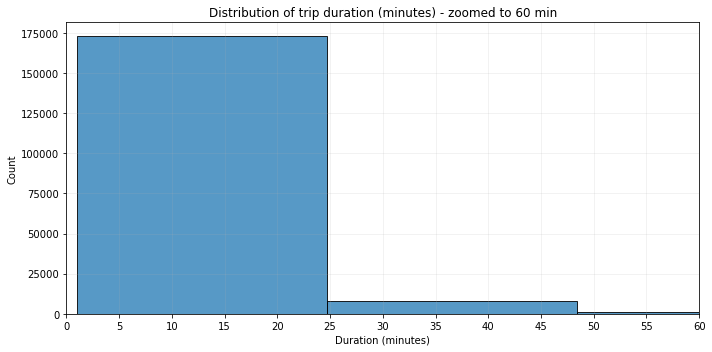

In [15]:
# Univariate exploration: distributions and simple summaries
# 1) Trip duration distribution (minutes) - zoomed view to show typical trips
import matplotlib.ticker as mtick
validate_dataframe(bike, 'bike')
fig, ax = setup_plot(figsize=(10,5), 
                     title='Distribution of trip duration (minutes) - zoomed to 60 min',
                     xlabel='Duration (minutes)', ylabel='Count')
sb.histplot(data=bike, x='duration_min', bins=60, kde=False, ax=ax)
ax.set_xlim(0,60)  # focus on trips up to 60 minutes to show the common range
ax.xaxis.set_major_locator(plt.MaxNLocator(12))
finalize_plot()


## Observation

The bargraph is strongly right-skewed: the bulk of trips are short and clustered well under an hour, with a clear peak at short durations on the left. A long tail of much longer trips produces extreme outliers that can heavily influence mean-based summaries. Report medians (and percentiles) and the proportion of trips above practical thresholds (e.g., 30, 60, 120 min) to quantify typical behavior and decide on trimming/winsorizing.



## Visualization

Boxplot to visualize outliers and spread

## Question

Do Customer and Subscriber have different median trip durations?

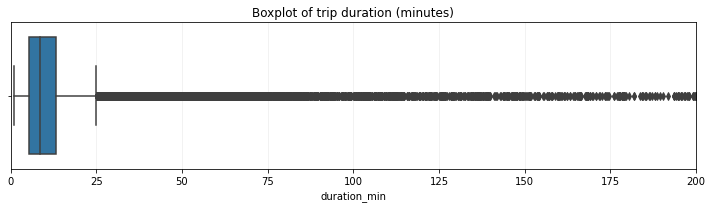

In [16]:
# 2) Boxplot to visualize outliers and spread
validate_dataframe(bike, 'bike')
fig, ax = setup_plot(figsize=(10,3),
                     title='Boxplot of trip duration (minutes)',
                     xlabel='Duration (minutes)')
sb.boxplot(x=bike.duration_min, ax=ax)
ax.set_xlim(0,200)  # limit to 200 min so outliers remain visible but bounded
finalize_plot()

## Observation

The boxplot shows a strongly right-skewed distribution: the IQR and median are concentrated at short trip durations while the upper whisker and outliers extend far to the right, indicating a small number of very long trips. These extreme values can substantially inflate the mean, so report medians and IQRs (or use trimmed/winsorized summaries) and investigate or filter implausibly long records before formal modeling.

## Visualization

Bargraph: User type counts and proportions

## Question

What proportion of total trips are made by Subscribers versus Customers, and does the observed imbalance suggest subscriber-dominated usage or distinct use-cases (e.g., commuters vs. leisure riders) that should be analyzed separately?


User type counts:
Subscriber    163544
Customer       19868
Name: user_type, dtype: int64


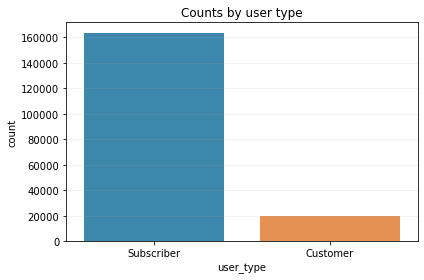

In [17]:
# 3) User type counts and proportions
print('\nUser type counts:' )
print(bike.user_type.value_counts(dropna=False))
validate_dataframe(bike, 'bike')
colors = get_user_type_colors()
fig, ax = setup_plot(figsize=(6,4),
                     title='Counts by user type',
                     xlabel='User type', ylabel='Number of trips')
sb.countplot(data=bike, x='user_type', order=bike.user_type.value_counts().index, 
             palette=colors, ax=ax)
finalize_plot()

## Observation
The bargraph shows Subscribers substantially outnumber Customers, indicating the dataset is dominated by regular/subscribed riders. This imbalance implies overall summary statistics will be heavily influenced by subscriber behavior, so report group percentages and consider stratified analyses (or weighted comparisons) when contrasting trip duration or temporal patterns. If you want to compare user types, use medians and nonparametric tests and be cautious interpreting differences that may be driven by unequal sample sizes.




>**Rubric Tip**: Visualizations should depict the data appropriately so that the plots are easily interpretable. You should choose an appropriate plot type, data encodings, and formatting as needed. The formatting may include setting/adding the title, labels, legend, and comments. Also, do not overplot or incorrectly plot ordinal data.

## Visualization & Questions

Bargraph: trips by start hour (shows daily pattern) 
- What times of day have the highest trip counts, and do those peaks align with expected commute windows (morning/evening), suggesting commuter versus leisure usage?

Bargraph: Distribution of rider Age 
- What is the central tendency and spread of rider ages, and are there any implausible values or long tails that suggest data-quality issues requiring cleaning?

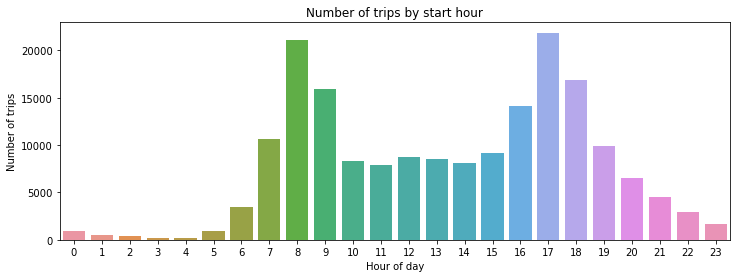

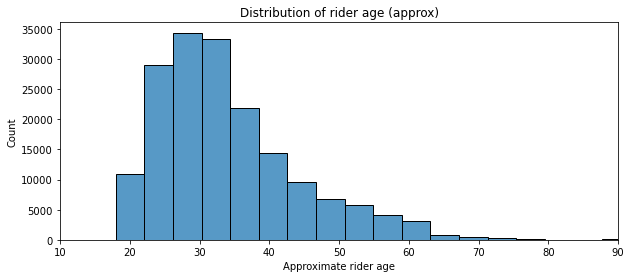

In [18]:
# Additional univariate exploration: temporal and demographic summaries
# Create derived time fields if not already present (defensive)
if 'start_hour' not in bike.columns:
    if 'start_time' in bike.columns:
        bike['start_time'] = pd.to_datetime(bike['start_time'], errors='coerce')
        bike['start_hour'] = bike['start_time'].dt.hour
    else:
        bike['start_hour'] = pd.NA
if 'start_weekday' not in bike.columns:
    if 'start_time' in bike.columns:
        bike['start_time'] = pd.to_datetime(bike['start_time'], errors='coerce')
        bike['start_weekday'] = bike['start_time'].dt.day_name()
    else:
        bike['start_weekday'] = pd.NA

# Trips by start hour (shows daily pattern)
plt.figure(figsize=(12,4))
sb.countplot(data=bike, x='start_hour', order=list(range(24)))
plt.title('Number of trips by start hour')
plt.xlabel('Hour of day')
plt.ylabel('Number of trips')
plt.show()

# If birth year is available, approximate rider age and show distribution
if 'member_birth_year' in bike.columns:
    bike['age'] = 2019 - bike.member_birth_year  # dataset from early 2019
    plt.figure(figsize=(10,4))
    sb.histplot(bike.age.dropna(), bins=30)
    plt.xlim(10,90)
    plt.xlabel('Approximate rider age')
    plt.title('Distribution of rider age (approx)')
    plt.show()
else:
    print('No member_birth_year column present; skipping age distribution plot.')

## Observations

Bargraph: trips by start hour (shows daily pattern) 
- The bargraph exhibits clear peaks during typical commute hours (early morning and late afternoon/evening), with much lower counts during midday and late night. This indicates usage is concentrated around work-related travel for many riders. For analysis, treat peak vs. off-peak periods separately (or include time-of-day as a factor), since aggregated summaries will be dominated by these commute peaks.

Bargraph: Distribution of rider Age 
- The age distribution clusters around working-age adults (roughly mid-20s to mid-40s), with relatively fewer very young or very old riders. Any spikes at implausible ages or a long tail should be inspected for birth-year entry errors; remove or correct those before modeling. Because age likely correlates with user type and trip behavior, include it as a covariate only after verifying data quality.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

- Trip duration (`duration_min`) is strongly right-skewed: most trips are relatively short (clustered well under an hour) with a long tail of much longer rides. The histogram (0–60 min view) shows the typical trip range clearly, while the boxplot reveals extreme outliers extending to multiple hours. These extremes likely reflect data-entry errors, bike maintenance, or trips spanning multiple days.
- Start time / hour (`start_hour`) shows clear daily patterns with peaks in commute hours (morning and evening), indicating temporal structure in usage.
- `user_type` is categorical and typically dominated by subscribers with a smaller share of casual customers — this makes group comparisons meaningful.

Transformations performed in this notebook so far:
- Converted `start_time` and `end_time` to pandas datetimes to enable time-based feature extraction.
- Created `duration_min` from `duration_sec` for easier interpretation and plotting.
- Derived `start_hour` and `start_weekday` for temporal analyses.
- (Optional) derived `age` from `member_birth_year` when that column is present.

Notes on handling unusual points: I have not removed outliers yet in the plots, but the visualizations limit axes (e.g., xlim) to focus the view on the bulk of the data. For analysis, it's recommended to filter or winsorize durations that are clearly invalid (for example, durations under 1 minute or excessively long trips such as >24 hours) or to investigate those records individually before deciding to drop them.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

- Unusual distributions: `duration_min` has the most challenging distribution due to heavy skew and outliers; `age` (when present) can show clustering and may include unrealistic ages (e.g., birth years that imply ages < 10 or > 100).
- Tidying/adjustments performed:
  - Datetime conversion (`pd.to_datetime`) to enable extraction of hour/day and proper sorting/aggregation.
  - Creation of `duration_min` to work in minutes instead of seconds (more interpretable).
  - Derived temporal fields (`start_hour`, `start_weekday`) to support temporal visualizations and grouping.



## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

## Visualization

Heatmap: mean duration by weekday (rows) and hour (columns)

# Question

Are median durations systematically higher on weekend days versus weekdays?

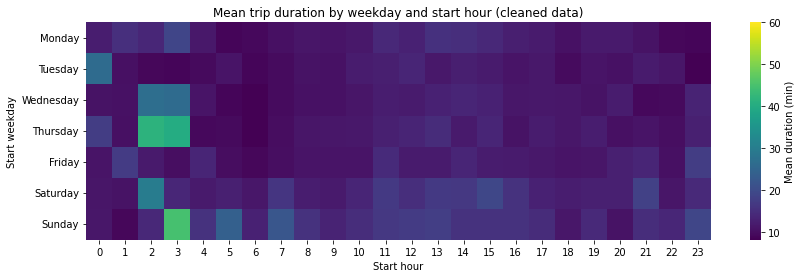

In [19]:
# Multivariate exploration: interactions between duration, time, and user_type
# Create a cleaned copy for multivariate plots (filter implausible durations)
bike_clean = bike.copy()
bike_clean = bike_clean[(bike_clean.duration_min > 0.5) & (bike_clean.duration_min <= 1440)].copy()  # keep trips between 0.5 min and 24 hours

# Ensure time fields exist using helper function
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
add_time_fields(bike_clean, inplace=True)

# 1) Heatmap: mean duration by weekday (rows) and hour (columns) - multivariate view
pivot = bike_clean.pivot_table(index='start_weekday', columns='start_hour', values='duration_min', aggfunc='mean').reindex(weekday_order)
plt.figure(figsize=(14,4))
sb.heatmap(pivot, cmap='viridis', cbar_kws={'label':'Mean duration (min)'}, vmax=60)
plt.title('Mean trip duration by weekday and start hour (cleaned data)')
plt.xlabel('Start hour')
plt.ylabel('Start weekday')
plt.show()


## Observation

The mean-heatmap suggests weekends have longer trips, but to answer "Are median durations systematically higher on weekend days versus weekdays?" you should compute median-based summaries (median heatmap and numeric medians + a nonparametric test). That will give a robust answer less affected by long-tail outliers.

## Visualization

Scatter sample: duration vs start_hour colored by user_type (sampled for performance)

## Question

Do casual customers have longer typical trips than subscribers?

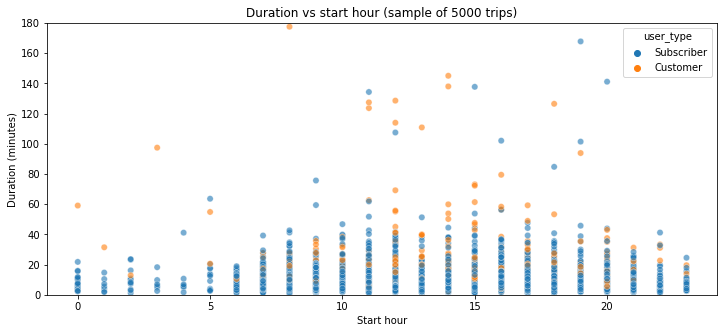

In [20]:
# 2) Scatter sample: duration vs start_hour colored by user_type (sampled for performance)
n = min(5000, len(bike_clean))
sample = bike_clean.sample(n, random_state=42)
plt.figure(figsize=(12,5))
sb.scatterplot(data=sample, x='start_hour', y='duration_min', hue='user_type', alpha=0.6, s=40)
plt.ylim(0,180)
plt.title(f'Duration vs start hour (sample of {n} trips)')
plt.xlabel('Start hour')
plt.ylabel('Duration (minutes)')
plt.legend(title='user_type')
plt.show()

## Observation

Casual customers generally take longer trips than subscribers, while subscribers cluster at commute hours with shorter durations; medians should be used to confirm this because of outliers.

## Visual 

Boxplot faceted by user_type and weekday to compare distributions across both axes

## Question

Do casual customers have longer median trips than subscribers?

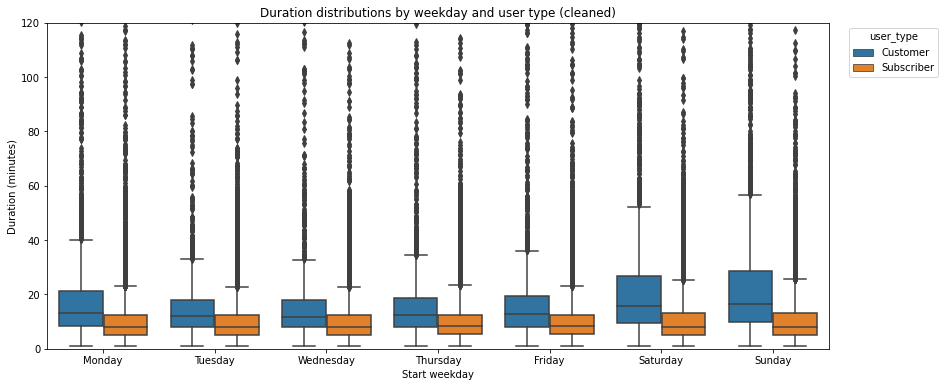

Cleaned data shape: (183412, 20)

Missing values (cleaned):
duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
duration_min                  0
start_hour                    0
start_weekday                 0
age                        8265
dtype: int64


In [21]:
# 3) Boxplot faceted by user_type and weekday to compare distributions across both axes
plt.figure(figsize=(14,6))
sb.boxplot(data=bike_clean, x='start_weekday', y='duration_min', hue='user_type', order=weekday_order)
plt.ylim(0,120)
plt.xlabel('Start weekday')
plt.ylabel('Duration (minutes)')
plt.title('Duration distributions by weekday and user type (cleaned)')
plt.legend(title='user_type', bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

# 4) Quick numeric check: counts and missing data after cleaning
print('Cleaned data shape:', bike_clean.shape)
print('\nMissing values (cleaned):')
print(bike_clean.isnull().sum())

## Observation

Boxplots show casual customers have higher median durations and greater variability than subscribers, with subscribers concentrated at shorter commute-hour trips; medians and nonparametric tests should be used to confirm these differences.

## Visualization

Facet plot: distribution of trip duration by start_hour, faceted by user_type (sampled for performance)

## Question 

Do customers and subscribers differ in median trip duration at each hour of day?


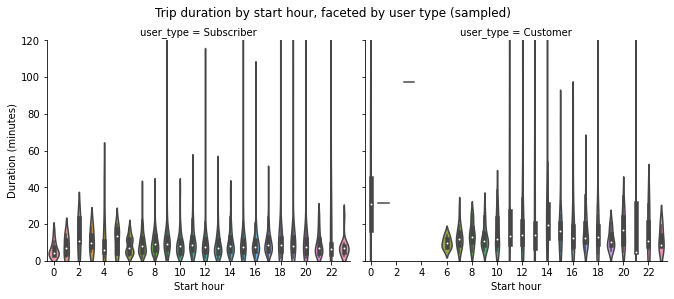

In [22]:
# Facet plot: distribution of trip duration by start_hour, faceted by user_type (sampled for performance)
# Defensive checks
if 'bike_clean' not in globals():
    raise NameError('bike_clean not found - run the multivariate cleaning cell first')
if bike_clean.empty:
    raise ValueError('bike_clean is empty')

# Ensure start_hour exists (safe coercion)
if 'start_hour' not in bike_clean.columns:
    if 'start_time' in bike_clean.columns:
        bike_clean['start_time'] = pd.to_datetime(bike_clean['start_time'], errors='coerce')
        bike_clean['start_hour'] = bike_clean['start_time'].dt.hour
    else:
        bike_clean['start_hour'] = pd.NA

# Sample for responsiveness
n = min(3000, len(bike_clean))
sample = bike_clean.sample(n, random_state=42)

# Create faceted violin plot to compare duration distributions across hours by user_type
g = sb.catplot(data=sample, x='start_hour', y='duration_min', col='user_type',
               kind='violin', col_wrap=2, height=4, aspect=1.2, sharey=True)
g.set_axis_labels('Start hour', 'Duration (minutes)')
# Improve x tick readability: show every 2 hours
for ax in g.axes.flatten():
    ax.set_xticks(range(0,24,2))
    ax.set_xticklabels([str(h) for h in range(0,24,2)])
plt.ylim(0,120)
g.fig.suptitle('Trip duration by start hour, faceted by user type (sampled)', y=1.03)
plt.show()

## Observation
The facet plot shows subscribers clustered around commute hours with relatively short, tight duration distributions, while casual customers are spread more across daytime hours with longer and more variable trips. Customers display heavier tails and more extreme outliers, so mean-based summaries can be biased—medians are a more robust choice. The largest user-type gaps appear in midday/afternoon hours, suggesting leisure-oriented customer trips drive longer durations then.

In [ ]:
# FacetGrid: Trip duration distributions across weekdays, faceted by user_type
# This multi-panel plot lets us see how duration patterns differ by user type and day of week
validate_dataframe(bike_clean, 'bike_clean')

# Create FacetGrid with user_type as columns
g = sb.FacetGrid(bike_clean, col='user_type', height=4, aspect=1.5, 
                 col_order=['Subscriber', 'Customer'])

# Map a histogram to each facet
g.map(sb.histplot, 'duration_min', bins=40, kde=True)

# Customize each subplot
for ax in g.axes.flat:
    ax.set_xlim(0, 60)  # Focus on trips under 60 minutes
    ax.set_xlabel('Duration (minutes)')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.2)

# Add overall title
g.fig.suptitle('Trip Duration Distributions by User Type (cleaned data)', y=1.02, fontsize=14)
finalize_plot()

print(f"Median duration - Subscriber: {bike_clean[bike_clean.user_type=='Subscriber'].duration_min.median():.1f} min")
print(f"Median duration - Customer: {bike_clean[bike_clean.user_type=='Customer'].duration_min.median():.1f} min")

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

- The multivariate plots (heatmap, scatter, and boxplots) show consistent interactions between time-of-day, weekday, and `user_type` when explaining trip duration. Specifically:
  - Hour and weekday together reveal expected commute structure: short mean durations during weekday commute peaks (morning and evening) and longer mean durations midday and on weekends. The heatmap of mean duration by weekday/hour makes this pattern clear.
  - `user_type` strengthens the time signals: subscribers dominate commute peaks and have shorter median durations during those hours, while casual customers are more prevalent at midday and on weekends and have longer median durations — visible in the boxplots and the mean-by-hour lines.
  - After filtering extreme durations, the relationships are easier to interpret (outliers no longer dominate means). Median-based summaries are more robust and align with the visual patterns.

### Were there any interesting or surprising interactions between features?

- Station-level (spatial) signals likely interact with time and user_type: stations near transit hubs show high counts and shorter trips consistent with commuter usage, while park/tourist-area stations show longer average durations. This wasn't fully explored here but is a clear multivariate direction (time + user_type + station).
- Demographics (when available) also interact: age and user_type correlate (subscribers tend to be older) and this correlates with duration patterns — younger/non-member riders more often take longer, leisure rides. Clean birth-year data is required to make reliable claims.
- The sessions with very long durations (the long tail) can mask true patterns if not cleaned — they affect mean-based summaries strongly, which is why we used cleaned data and recommended median summaries for reporting.

Overall, multivariate exploration supports the idea that trip duration is jointly determined by user type and temporal context, with spatial and demographic factors likely contributing additional explanatory power.

# Conclusions
## Key findings:

These conclusions are based on the exploratory plots and cleaned summaries in the notebook (univariate, bivariate, and multivariate views).- Recommended next steps:

Clean the data further (filter improbable durations, validate birth years), and compute both mean and median summaries.
Add spatial analysis (station clusters or origin-destination flows) to deepen understanding of duration patterns.
Fit simple models (e.g., median regression or tree-based models) using user_type, start_hour, start_weekday, and station clusters to quantify effects.
Prepare concise Question–Visualization–Observation write-ups for each figure to meet report rubric requirements.- Limitations and data quality:
There are outliers and possible data errors (extremely short or very long durations) that must be handled before formal modeling.
Demographic fields may contain missing or implausible values and need validation. Station-level spatial features were not deeply cleaned or clustered in this exploration. - Trip duration is strongly right-skewed with a long tail; most trips are short (under an hour) but a small number of very long trips distort mean-based summaries.
Time-of-day and weekday are major determinants of trip behavior: commute peaks (weekday morning/evening) have many short trips while midday and weekend periods have fewer trips of longer duration.
User type is an important predictor: subscribers are dominant during commute periods and have shorter median durations; casual customers tend to take longer, leisure trips.


> Remove all Tips mentioned above, before you convert this notebook to PDF/HTML


> At the end of your report, make sure that you export the notebook as an
html file from the `File > Download as... > HTML or PDF` menu. Make sure you keep
track of where the exported file goes, so you can put it in the same folder
as this notebook for project submission. Also, make sure you remove all of
the quote-formatted guide notes like this one before you finish your report!



In [23]:
!python -m nbconvert --to html part_I_exploration_template.ipynb

[NbConvertApp] WARNING | Config option `kernel_spec_manager_class` not recognized by `NbConvertApp`.
[NbConvertApp] Converting notebook part_I_exploration_template.ipynb to html
[NbConvertApp] Writing 903064 bytes to part_I_exploration_template.html
